In [5]:
import numpy as np
import matplotlib.pyplot as plt

import tt
from tt.cross.rectcross import cross as tt_cross

rng = np.random.default_rng()

In [6]:
class diffusion_coeff:
  def __init__(self, Nx, Ny, offset, var):
    self.Nx = Nx
    self.Ny = Ny
    self.offset = offset
    self.var = var

  def __call__(self, X):
    c = np.full(len(X), self.offset,dtype=float)
    for i, x in enumerate(X):
      k = np.arange(1,len(x)-1)
      # k = k[k != 7]
      c[i] += np.sum(k**-2. * np.sin(np.pi*k*x[0]/(self.Nx-1)) \
                      * (x[k+1]/(self.Ny-1) - 0.5) * self.var)
    return c

In [7]:
Nx = 100    # spatial resolution
Ny = 5       # parameter resolution
n_a_param = 8 # number of parameters for diffusion coeff
n_param = n_a_param
offset = 1   # parameter mean
var = 4       # 'variance' of the parameters

cfun = diffusion_coeff(Nx, Ny, offset, var)

tol = 1e-3

param_shape = tuple([Ny] * n_param)

C_a = tt.rand(np.array((Nx,) + param_shape), r=Ny)

C_a = tt.cross.rect_cross.cross(cfun, C_a, eps = 1e-4, kickrank=1)
C_a = C_a.round(1e-12)

print("Coefficient ranks: ", C_a.r)
print("Coefficient dims: ", C_a.n)

swp: 0/9 er_rel = 4.7e+02 er_abs = 4.0e+06 erank = 7.7 fun_eval: 3995
swp: 1/9 er_rel = 1.4e-01 er_abs = 1.2e+03 erank = 12.7 fun_eval: 13265
swp: 2/9 er_rel = 5.1e-02 er_abs = 4.6e+02 erank = 18.0 fun_eval: 32945
swp: 3/9 er_rel = 1.6e-15 er_abs = 1.5e-11 erank = 23.4 fun_eval: 67205
Coefficient ranks:  [1 8 8 7 6 5 4 3 2 1]
Coefficient dims:  [100   5   5   5   5   5   5   5   5]


RMS l2 err = 1.19e-15


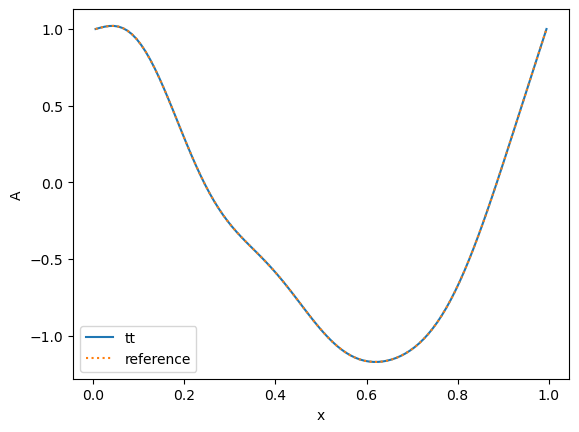

In [8]:
N_MC = 500
errs = np.zeros(N_MC)

for i in range(N_MC):
  # eval TT-approx of coeff
  y = rng.integers(0, Ny, n_a_param)
  C_eval = np.zeros(Nx)
  for i in range(Nx):
    C_eval[i] = C_a[i, *y]

  X = np.hstack([np.arange(Nx).reshape((-1,1)), np.tile(y, [Nx,1])])
  C_true = cfun(X)

  errs[i] = np.linalg.norm(C_eval-C_true)

print(f'RMS l2 err = {np.sqrt(np.mean(np.square(errs))):.2e}')

fig, ax = plt.subplots()

x = (np.arange(0, Nx) + .5) / Nx
ax.plot(x, C_eval, label='tt')
ax.plot(x, C_true, ls='dotted', label="reference")
ax.set_xlabel('x')
ax.set_ylabel('A')
ax.legend()